In [26]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [ ]:
# ==============================
# DATASET LOADING (CIFAR-10)
# ==============================

import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Transformações (normalização + tensor)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), 
                         (0.5, 0.5, 0.5))
])

# Download dataset
trainset = torchvision.datasets.CIFAR10(
    root='../data',
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root='../data',
    train=False,
    download=True,
    transform=transform
)

# DataLoaders
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=8,
    shuffle=True
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=8,
    shuffle=False
)

# Classes
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print("Dataset loaded successfully")

Dataset loaded successfully


bird horse frog deer dog horse truck truck


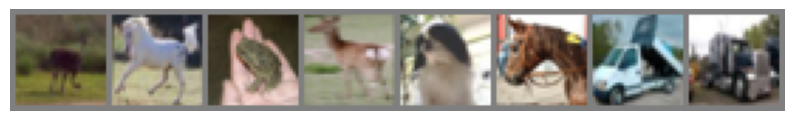

In [28]:
# ==============================
# VISUALIZE DATA
# ==============================

# função para mostrar imagem
def imshow(img):
    img = img / 2 + 0.5  # desnormalizar
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')

# obter batch
dataiter = iter(trainloader)
images, labels = next(dataiter)

# mostrar imagens
plt.figure(figsize=(10, 4))
imshow(torchvision.utils.make_grid(images))

# labels
print(' '.join(f'{classes[labels[j]]}' for j in range(8)))

In [29]:
# ==============================
# CNN MODEL
# ==============================

import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        
        # Convolution layers
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        
        # Pooling
        self.pool = nn.MaxPool2d(2, 2)
        
        # Fully connected
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # Conv + ReLU + Pool
        x = self.pool(F.relu(self.conv1(x)))   # 32x32 → 16x16
        x = self.pool(F.relu(self.conv2(x)))   # 16x16 → 8x8
        
        # Flatten
        x = x.view(-1, 32 * 8 * 8)
        
        # FC layers
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        
        return x

# Instanciar modelo
model = SimpleCNN().to(device)

print(model)

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [30]:
# ==============================
# LOSS & OPTIMIZER
# ==============================

import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Setup complete")

Setup complete


In [31]:
# ==============================
# TRAINING LOOP
# ==============================

epochs = 2  # rápido para testar

for epoch in range(epochs):
    running_loss = 0.0
    
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        # reset gradients
        optimizer.zero_grad()

        # forward
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # backward
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if i % 2000 == 1999:
            print(f'Epoch {epoch+1}, Batch {i+1}, Loss: {running_loss/2000:.3f}')
            running_loss = 0.0

print("Training finished")

Epoch 1, Batch 2000, Loss: 1.544
Epoch 1, Batch 4000, Loss: 1.230
Epoch 1, Batch 6000, Loss: 1.101
Epoch 2, Batch 2000, Loss: 0.967
Epoch 2, Batch 4000, Loss: 0.935
Epoch 2, Batch 6000, Loss: 0.920
Training finished


In [32]:
# ==============================
# SAVE MODEL
# ==============================

import os

os.makedirs("../models", exist_ok=True)

torch.save(model.state_dict(), "../models/model.pth")

print("Model saved!")

Model saved!


In [33]:
# ==============================
# MODEL EVALUATION
# ==============================

correct = 0
total = 0

with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy: {accuracy:.2f}%')

Accuracy: 66.91%


Predicted:  cat ship car plane frog frog car frog
Actual:     cat ship ship plane frog frog car frog


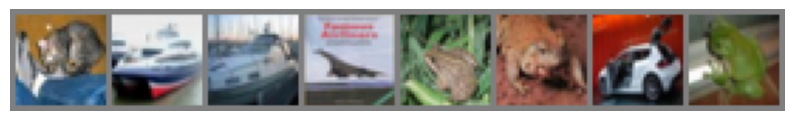

In [34]:
# ==============================
# SHOW PREDICTIONS
# ==============================

dataiter = iter(testloader)
images, labels = next(dataiter)

images, labels = images.to(device), labels.to(device)

outputs = model(images)
_, predicted = torch.max(outputs, 1)

# mostrar imagens
plt.figure(figsize=(10,4))
imshow(torchvision.utils.make_grid(images.cpu()))

print("Predicted: ", ' '.join(f'{classes[predicted[j]]}' for j in range(8)))
print("Actual:    ", ' '.join(f'{classes[labels[j]]}' for j in range(8)))

In [35]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [36]:
from src.gradcam import GradCAM
import cv2

def show_cam_on_image(img, cam):
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255
    overlay = heatmap + np.float32(img)
    overlay = overlay / np.max(overlay)
    return overlay

In [37]:
def show_cam_on_image(img, cam):
    cam = cv2.resize(cam, (img.shape[1], img.shape[0]))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255

    overlay = heatmap + np.float32(img)
    overlay = overlay / np.max(overlay)

    return overlay

/Volumes/Lexar/IMPACT/IMPK-AI-Portfolio/impk-deep-learning-gradcam/src/gradcam.py:34: RuntimeWarning: invalid value encountered in divide
  
/var/folders/5w/_glz1m517zq2hdq2sbxfy4r00000gn/T/ipykernel_94453/490125783.py:4: RuntimeWarning: invalid value encountered in cast
  heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)


(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

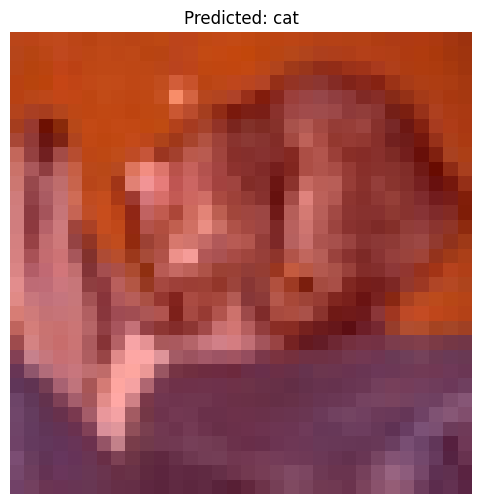

In [38]:
# ==============================
# GRAD-CAM
# ==============================

# escolher camada (última conv)
target_layer = model.conv2

gradcam = GradCAM(model, target_layer)

# garantir que usamos a mesma batch das previsões
img = images[0].unsqueeze(0).to(device)

cam = gradcam.generate(img, predicted[0].item())

# preparar imagem para visualização
img_np = images[0].cpu().permute(1,2,0).numpy()
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

result = show_cam_on_image(img_np, cam)

plt.figure(figsize=(6,6))
plt.imshow(result)
plt.title(f"Predicted: {classes[predicted[0]]}", fontsize=12)
plt.axis('off')

In [39]:
import os
from datetime import datetime

os.makedirs("../results/images", exist_ok=True)
os.makedirs("../results/gradcam", exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

overlay_path = f"../results/gradcam/gradcam_{timestamp}.png"
original_path = f"../results/images/original_{timestamp}.png"
heatmap_path = f"../results/gradcam/heatmap_{timestamp}.png"

plt.imsave(original_path, img_np)
plt.imsave(heatmap_path, cam, cmap="jet")

plt.figure(figsize=(6, 6))
plt.imshow(result)
plt.axis("off")
plt.savefig(overlay_path, bbox_inches="tight")
plt.close()

print("Saved files:")
print(original_path)
print(heatmap_path)
print(overlay_path)

Saved files:
../results/images/original_20260425_174639.png
../results/gradcam/heatmap_20260425_174639.png
../results/gradcam/gradcam_20260425_174639.png


In [40]:
import os
from datetime import datetime

# ==============================
# CREATE FOLDERS
# ==============================
os.makedirs("../results/images", exist_ok=True)
os.makedirs("../results/gradcam", exist_ok=True)

# ==============================
# TIMESTAMP
# ==============================
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# ==============================
# FILE PATHS
# ==============================
overlay_path = f"../results/gradcam/gradcam_{timestamp}.png"
original_path = f"../results/images/original_{timestamp}.png"
heatmap_path = f"../results/gradcam/heatmap_{timestamp}.png"

# ==============================
# SAVE ORIGINAL IMAGE
# ==============================
plt.imsave(original_path, img_np)

# ==============================
# SAVE HEATMAP (RAW CAM)
# ==============================
plt.imsave(heatmap_path, cam, cmap='jet')

# ==============================
# SAVE OVERLAY (FINAL RESULT)
# ==============================
plt.figure(figsize=(6,6))
plt.imshow(result)
plt.axis('off')
plt.savefig(overlay_path, bbox_inches='tight')
plt.close()

print("Saved files:")
print(original_path)
print(heatmap_path)
print(overlay_path)

Saved files:
../results/images/original_20260425_174639.png
../results/gradcam/heatmap_20260425_174639.png
../results/gradcam/gradcam_20260425_174639.png


In [41]:
from src.model import SimpleCNN

In [42]:
import os

os.makedirs("../models", exist_ok=True)
torch.save(model.state_dict(), "../models/model.pth")
print("Model saved!")

Model saved!
